<a href="https://colab.research.google.com/github/Its-SSN/Thesis/blob/main/Deepsurv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.sample(5)

Mounted at /content/drive


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,No
1846,7369-TRPFD,Male,0,No,No,19,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,18.80,279.2,No
4586,7569-NMZYQ,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),118.75,8672.45,No
2672,2150-OEGBV,Male,0,No,No,27,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.10,562.6,No
2843,9371-BITHB,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,1070.5,No


In [4]:
df.drop('customerID',axis='columns',inplace=True)
df1 = df[df.TotalCharges!=' ']
df1.shape

(7032, 20)

In [5]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

/tmp/ipykernel_2667/973151263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.TotalCharges = pd.to_numeric(df1.TotalCharges)


In [6]:
!pip install pycox torchtuples

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 9.4 MB/s eta 0:00:00
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2434 sha256=393c5ce3a85193d4e8bb8af7531a2b8f963cd88858f605f869a227fae6e664bf
  Stored in directory: /root/.cache/pip/wheels/dd/02/6b/2f0f7e1c0454094c880e63076da142e67f1ba72f82baa6195f
Successfully built feather-format


In [7]:
import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Prepare Data
df1['Churn_event'] = df1['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
features = ['MonthlyCharges', 'TotalCharges'] # tenure is our 'time' variable

X = df1[features].astype('float32')
y_time = df1['tenure'].values.astype('float32')
y_event = df1['Churn_event'].values.astype('float32')

# Split data
X_train, X_test, t_train, t_test, e_train, e_test = train_test_split(
    X, y_time, y_event, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PyCox expects tuples for targets
train_target = (t_train, e_train)
test_target = (t_test, e_test)

/tmp/ipykernel_2667/1038924235.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Churn_event'] = df1['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)


In [8]:
# 2. Build the Neural Network
in_features = X_train.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1
output_bias = False

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)

# 3. Initialize DeepSurv (CoxPH) Model
model = CoxPH(net, torch.optim.Adam)

# 4. Train the Model
batch_size = 256
epochs = 100
callbacks = [tt.callbacks.EarlyStopping()]

log = model.fit(X_train, train_target, batch_size, epochs, callbacks,
                val_data=(X_test, test_target), verbose=True)

0:	[0s / 0s],		train_loss: 4.8929,	val_loss: 6.1765
1:	[0s / 0s],		train_loss: 4.2219,	val_loss: 5.6498
2:	[0s / 0s],		train_loss: 3.9012,	val_loss: 5.3843
3:	[0s / 0s],		train_loss: 3.7382,	val_loss: 5.2188
4:	[0s / 1s],		train_loss: 3.5678,	val_loss: 5.0838
5:	[0s / 1s],		train_loss: 3.4824,	val_loss: 4.9698
6:	[0s / 1s],		train_loss: 3.3925,	val_loss: 4.8661
7:	[0s / 2s],		train_loss: 3.3026,	val_loss: 4.7748
8:	[0s / 2s],		train_loss: 3.2259,	val_loss: 4.6970
9:	[0s / 2s],		train_loss: 3.1534,	val_loss: 4.6294
10:	[0s / 2s],		train_loss: 3.1220,	val_loss: 4.5665
11:	[0s / 3s],		train_loss: 3.1053,	val_loss: 4.5236
12:	[0s / 3s],		train_loss: 3.0725,	val_loss: 4.4813
13:	[0s / 3s],		train_loss: 3.0485,	val_loss: 4.4405
14:	[0s / 3s],		train_loss: 2.9892,	val_loss: 4.4166
15:	[0s / 3s],		train_loss: 2.9346,	val_loss: 4.3827
16:	[0s / 3s],		train_loss: 2.9655,	val_loss: 4.3535
17:	[0s / 4s],		train_loss: 2.9275,	val_loss: 4.3382
18:	[0s / 4s],		train_loss: 2.9314,	val_loss: 4.3193
19:

In [9]:
# 5. Evaluation using Concordance Index
_ = model.compute_baseline_hazards()
surv = model.predict_surv_df(X_test)
eval_surv = EvalSurv(surv, t_test, e_test, censor_surv='km')
print(f"Concordance Index: {eval_surv.concordance_td():.4f}")

Concordance Index: 0.9649


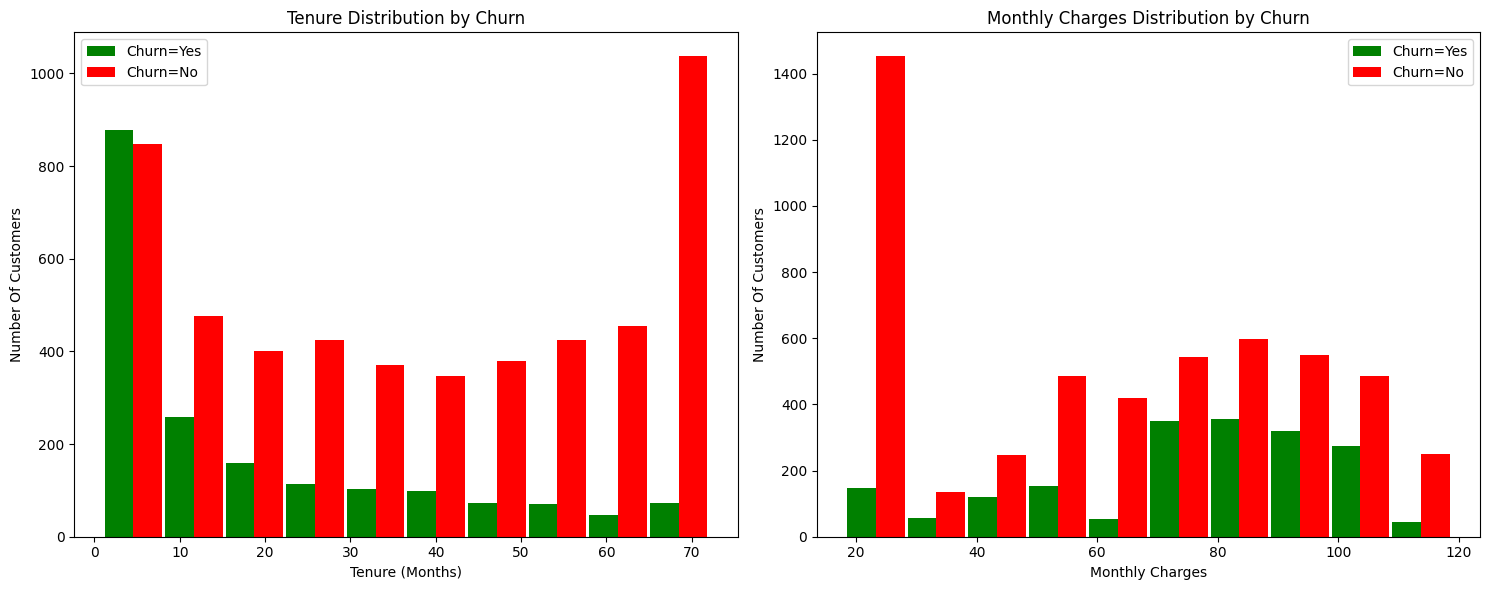

In [15]:
# Visualize Tenure and Monthly Charges Distribution for Churn vs Non-Churn
import matplotlib.pyplot as plt

tenure_churn_no = df1[df1.Churn==0].tenure
tenure_churn_yes = df1[df1.Churn==1].tenure

mc_churn_no = df1[df1.Churn==0].MonthlyCharges
mc_churn_yes = df1[df1.Churn==1].MonthlyCharges

plt.figure(figsize=(15, 6))

# Plot Tenure
plt.subplot(1, 2, 1)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number Of Customers')
plt.title('Tenure Distribution by Churn')
plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['green','red'], label=['Churn=Yes','Churn=No'])
plt.legend()

# Plot Monthly Charges
plt.subplot(1, 2, 2)
plt.xlabel('Monthly Charges')
plt.ylabel('Number Of Customers')
plt.title('Monthly Charges Distribution by Churn')
plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['green','red'], label=['Churn=Yes','Churn=No'])
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
#Adding more features-
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df1[col].replace({'Yes': 1,'No': 0},inplace=True)

/tmp/ipykernel_2667/3272376952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No internet service','No',inplace=True)
/tmp/ipykernel_2667/3272376952.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No phone service','No',inplace=True)
/tmp/ipykernel_2667/3272376952.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 

In [11]:
for col in df1:
    print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]
Churn_event: [0 1]


In [12]:
df1['gender'].replace({'Female':1,'Male':0},inplace=True)

/tmp/ipykernel_2667/698335744.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].replace({'Female':1,'Male':0},inplace=True)
/tmp/ipykernel_2667/698335744.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['gender'].replace({'Female':1,'Male':0},inplace=True)
/tmp/ipykernel_2667/

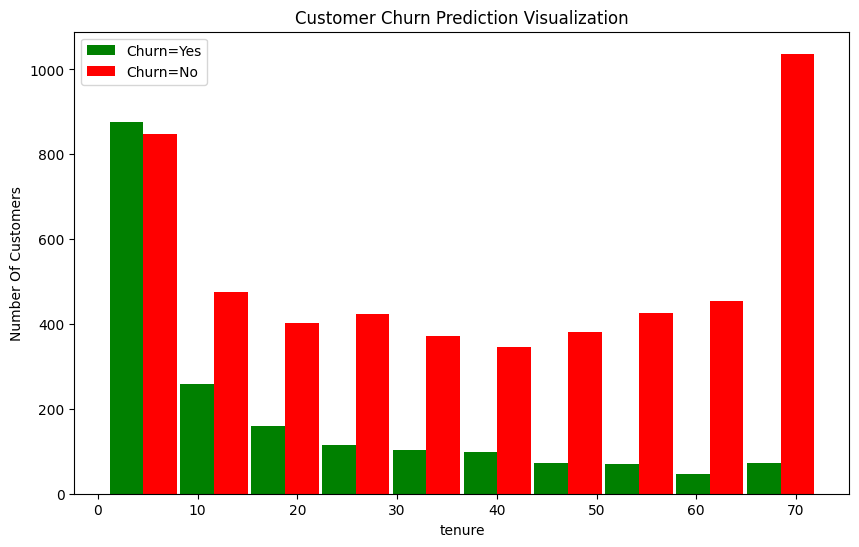

In [13]:
# Visualize Tenure Distribution for Churn vs Non-Churn
tenure_churn_no = df1[df1.Churn==0].tenure
tenure_churn_yes = df1[df1.Churn==1].tenure

plt.figure(figsize=(10, 6))
plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualization")

plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()
plt.show()

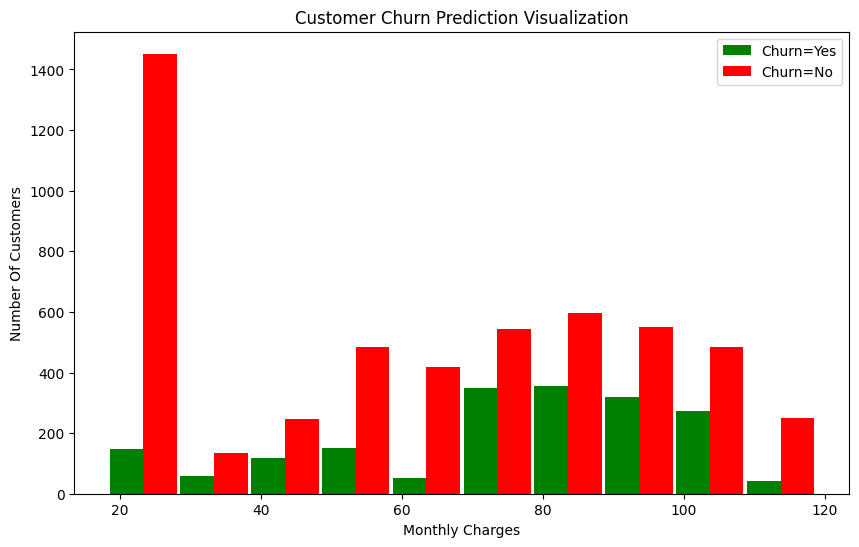

In [14]:
# Visualize Monthly Charges Distribution for Churn vs Non-Churn
mc_churn_no = df1[df1.Churn==0].MonthlyCharges
mc_churn_yes = df1[df1.Churn==1].MonthlyCharges

plt.figure(figsize=(10, 6))
plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualization")

plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()
plt.show()